In [1]:
from pathlib import Path
import copy
import pandas as pd
import datetime
from datetime import datetime
from liblaf import grapes
import polars as pl


In [ ]:
from qoc.market import  BinanceMarketData,BinanceDataCollectionFuturesUm
market_data: BinanceMarketData = BinanceDataCollectionFuturesUm()


symbols: list[str] = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'FTMUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'PENGUUSDT', 'TRUMPUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MOVRUSDT', 'DYMUSDT', 'NOTUSDT', 'SPXUSDT']
interval: str = "1m"


start: str = "2025-10-15"
end: str  = "2026-12-31"
    
market_data: BinanceMarketData = BinanceDataCollectionFuturesUm()



In [3]:
with grapes.timer():

    coins_dict: dict[str, pl.DataFrame] = await market_data.klines_batch(
        symbols, interval, start, end
    )

In [4]:
hedge_list = {k: v for k, v in coins_dict.items() if k in symbols}


# Preload

In [5]:

temp = copy.copy(hedge_list)

In [6]:
hedge_list = temp

In [7]:

import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from collections import deque
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import random
import os


In [8]:
len(hedge_list.keys())

43

In [9]:
start_time = datetime.strptime(start, "%Y-%m-%d")
end_time = datetime.strptime(end, "%Y-%m-%d")

In [10]:
start_time = start
end_time = end

In [11]:
for symbol, df in hedge_list.items():
    df = pd.DataFrame(df.to_dicts())
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms').dt.tz_localize(None)
    df['close_time'] = pd.to_datetime(df['close_time'], unit='ms').dt.tz_localize(None)

    df.set_index('open_time', inplace=True)
    # print(df.index.min(), df.index.max())
    hedge_list[symbol] = df[(df.index >= start_time) & (df.index <= end_time)]

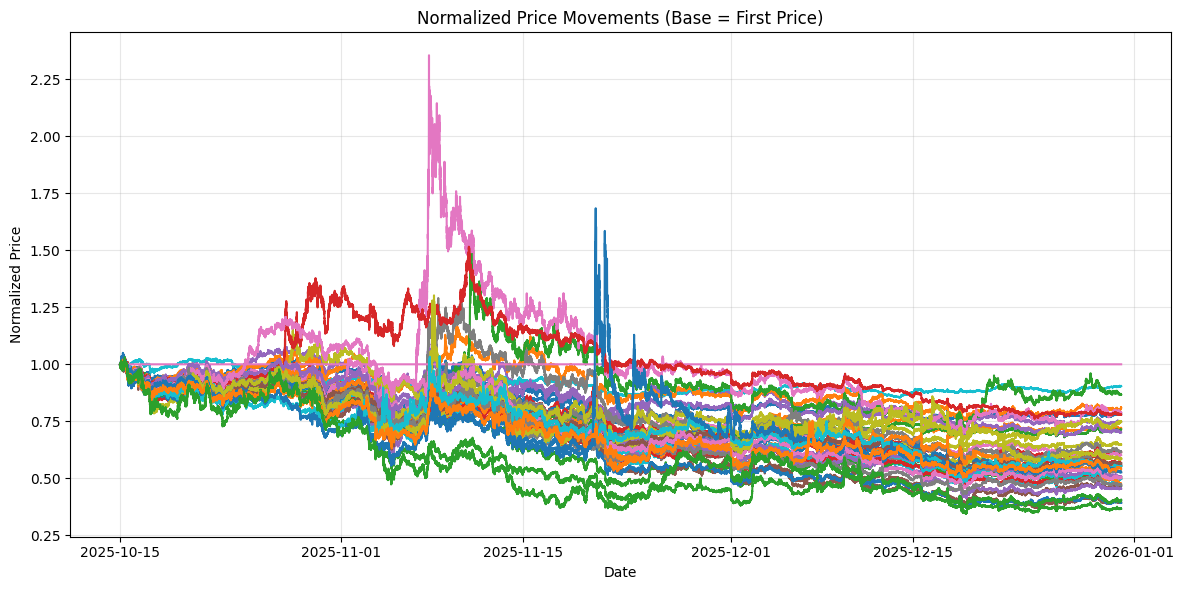

In [12]:
plt.figure(figsize=(12, 6))
for symbol, df in hedge_list.items():
    if len(df) > 0:  # Check if dataframe is not empty
        # Normalize to first price
        normalized_prices = df["close"] / df["close"].iloc[0]
        plt.plot(df.index, normalized_prices, label=symbol)

plt.title('Normalized Price Movements (Base = First Price)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

## Para

In [13]:

FORWARD_WINDOW =6
BACK_WINDOW = 12
BULLET_SIZE = 50

# Stats

## AMIHUD

In [14]:
amihud_window = BACK_WINDOW
for symbol, df in hedge_list.items():
    df["close_x_volume"] = df["close"] * df["volume"]
    df["Amihud"] = df["close_x_volume"].diff().abs()/df["close_x_volume"].rolling(window=amihud_window).mean() 
    df.dropna(inplace=True)   

## Split

In [15]:
# Remove MATICUSDT from hedge_list

if 'MATICUSDT' in hedge_list:
    del hedge_list['MATICUSDT']
    print("MATICUSDT removed from hedge_list")
else:
    print("MATICUSDT not found in hedge_list")

print(f"Remaining symbols in hedge_list: {list(hedge_list.keys())}")

if 'FTMUSDT' in hedge_list:
    del hedge_list['FTMUSDT']
    print("FTMUSDT removed from hedge_list")
else:
    print("FTMUSDT not found in hedge_list")

print(f"Remaining symbols in hedge_list: {list(hedge_list.keys())}")

MATICUSDT not found in hedge_list
Remaining symbols in hedge_list: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'FTMUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'PENGUUSDT', 'TRUMPUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MOVRUSDT', 'DYMUSDT', 'NOTUSDT', 'SPXUSDT']
FTMUSDT removed from hedge_list
Remaining symbols in hedge_list: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'PENGUUSDT', 'TRUMPUSDT

In [16]:
split_date = datetime(2025, 9, 1)

train_list = {}
test_list = {}

for symbol, df in hedge_list.items():
    train_list[symbol] = df[df.index < split_date]
    test_list[symbol] = df[df.index >= split_date]

In [29]:
data_list = test_list
common_index = None
for symbol, df in data_list.items():
    if common_index is None:
        common_index = df.index
    else:
        common_index = common_index.intersection(df.index)

## Regress

In [30]:

back_window = BACK_WINDOW
forward_window = FORWARD_WINDOW
bullet_size = BULLET_SIZE


# btc_close = deque(btc['close'][:back_window], maxlen=back_window)
coin_closes = {name: deque(df['close'][:back_window], maxlen=back_window) for name, df in hedge_list.items()}


# btc_volume = deque(btc['volume'][:back_window], maxlen=back_window)
coin_volumes = {name: deque(df['volume'][:back_window], maxlen=back_window) for name, df in hedge_list.items()}


xy_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
xx_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
yy_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
x_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
y_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}


xy_1_sum = {name: 0 for name in hedge_list.keys()}
xx_1_sum = {name: 0 for name in hedge_list.keys()}
yy_1_sum = {name: 0 for name in hedge_list.keys()}
x_1_sum = {name: 0 for name in hedge_list.keys()}
y_1_sum = {name: 0 for name in hedge_list.keys()}

# Trade

In [31]:
lc = None
sc = None
sam = 0
dif = 0

In [32]:
windows = [1, 4, 16, 64, 256]
for i in range(len(windows)):
    windows[i]*= BACK_WINDOW
windows

[12, 48, 192, 768, 3072]

In [33]:
# Initialize coef_records
coef_records = {}

revenues = []


# regression stats
    # Residual difference between short and long
    # Residual mean/std

    # Residual z-score all
    # Residual z-score selected
    # Residual sign

    # corr all
    # corr selected

stats_global = {
    "residual_diff": [],
    "residual_std": [],
    "residual_mean": [],
    "residual_z_all": [],
    "residual_z_selected": [],
    "residual_sign": [],
    "corr_all": [],
    "corr_selected": [],
    "coef_adj_all": [],
    "coef_adj_selected": [],
}


# stats by windows
    # growth diff all
    # growth diff selected
    # growth diff sign

    # Amihud all
    # Amihud selected

    # CMI all
    # CMI selected

    # coin score all
    # coin score selected

    # ATR all
    # ATR selected

    # Bollinger Bands all
    # Bollinger Bands selected

    # Volatility all
    # Volatility selected

stats_by_window = {
    "growth_diff_all": {w: [] for w in windows},
    "growth_diff_selected": {w: [] for w in windows},
    "growth_diff_sign": {w: [] for w in windows},

    "amihud_all": {w: [] for w in windows},
    "amihud_selected": {w: [] for w in windows},

    "cmi_all": {w: [] for w in windows},
    "cmi_selected": {w: [] for w in windows},

    "coin_all": {w: [] for w in windows},
    "coin_selected": {w: [] for w in windows},

    "atr_all": {w: [] for w in windows},
    "atr_selected": {w: [] for w in windows},

    "bb_all": {w: [] for w in windows},
    "bb_selected": {w: [] for w in windows},

    "vol_all": {w: [] for w in windows},
    "vol_selected": {w: [] for w in windows},
}



temp_score = {name: 0 for name in hedge_list.keys()}
temp_scores = {name: deque([0] * (forward_window + 1), maxlen=forward_window + 1) for name in hedge_list.keys()}

In [34]:
temp_scores

{'BTCUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'ETHUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'BNBUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'SOLUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'XRPUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'ADAUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'DOGEUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'AVAXUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'LINKUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'TRXUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'DOTUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'LTCUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'UNIUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'ATOMUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'ETCUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'APTUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'FILUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'NEARUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'HBARUSDT': deque([0, 0, 0, 0, 0, 0, 0], maxlen=7),
 'INJU

In [35]:
import warnings
warnings.filterwarnings('ignore')

In [36]:
print(common_index.min(), common_index.max(), len(common_index))
for name, df in train_list.items():
    print(name, df.index.min(), df.index.max(), len(df))


2025-10-15 00:11:00 2025-12-31 00:00:00 110870
BTCUSDT NaT NaT 0
ETHUSDT NaT NaT 0
BNBUSDT NaT NaT 0
SOLUSDT NaT NaT 0
XRPUSDT NaT NaT 0
ADAUSDT NaT NaT 0
DOGEUSDT NaT NaT 0
AVAXUSDT NaT NaT 0
LINKUSDT NaT NaT 0
TRXUSDT NaT NaT 0
DOTUSDT NaT NaT 0
LTCUSDT NaT NaT 0
UNIUSDT NaT NaT 0
ATOMUSDT NaT NaT 0
ETCUSDT NaT NaT 0
APTUSDT NaT NaT 0
FILUSDT NaT NaT 0
NEARUSDT NaT NaT 0
HBARUSDT NaT NaT 0
INJUSDT NaT NaT 0
OPUSDT NaT NaT 0
ARBUSDT NaT NaT 0
SUIUSDT NaT NaT 0
SEIUSDT NaT NaT 0
RENDERUSDT NaT NaT 0
TIAUSDT NaT NaT 0
EGLDUSDT NaT NaT 0
AAVEUSDT NaT NaT 0
GALAUSDT NaT NaT 0
IMXUSDT NaT NaT 0
WIFUSDT NaT NaT 0
PENGUUSDT NaT NaT 0
TRUMPUSDT NaT NaT 0
POLUSDT NaT NaT 0
ENSUSDT NaT NaT 0
JUPUSDT NaT NaT 0
PYTHUSDT NaT NaT 0
ORDIUSDT NaT NaT 0
MOVRUSDT NaT NaT 0
DYMUSDT NaT NaT 0
NOTUSDT NaT NaT 0
SPXUSDT NaT NaT 0


In [37]:






for i, t in tqdm(enumerate(common_index), desc="Processing timestamps", total=len(common_index)):
    # Only access data if timestamp exists in all dataframes
    for name, df in data_list.items():
        if t in df.index:
            coin_closes[name].append(df.loc[t, "close"])
            coin_volumes[name].append(df.loc[t, "volume"])
        else:
            print(f"Timestamp {t} not found in {name}, skipping...")
            continue

    if i>=back_window:
        for name, _ in data_list.items():
            if t not in data_list[name].index:
                continue
                
            # growth = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[-2]) 
            # mkt_idx_diff = coin_closes['BTCUSDT'][-1] - coin_closes['BTCUSDT'][-2]                
            growth = (np.array(coin_closes[name])[-1]) 
            mkt_idx_diff = coin_closes['BTCUSDT'][-1]
            
            if len(xy_1[name])>=back_window:
                xy_1_sum[name] -= xy_1[name][0]
                xx_1_sum[name] -= xx_1[name][0]
                yy_1_sum[name] -= yy_1[name][0]
                x_1_sum[name] -= x_1[name][0]
                y_1_sum[name] -= y_1[name][0]

                xy_1[name].popleft()
                xx_1[name].popleft()
                yy_1[name].popleft()
                x_1[name].popleft()
                y_1[name].popleft()

            xy_1[name].append(growth*mkt_idx_diff)
            xx_1[name].append(mkt_idx_diff**2)
            yy_1[name].append(growth**2)
            x_1[name].append(mkt_idx_diff)
            y_1[name].append(growth)
            
            xy_1_sum[name] += xy_1[name][-1]
            xx_1_sum[name] += xx_1[name][-1]
            yy_1_sum[name] += yy_1[name][-1]
            x_1_sum[name] += x_1[name][-1]
            y_1_sum[name] += y_1[name][-1]
            
            if i >= 2*back_window:
                # Without intercept
                coef_1 = xy_1_sum[name]/xx_1_sum[name] if xx_1_sum[name]!=0 else 0
                residual = np.array(coin_closes[name])[-1] - (coef_1 * (np.array(coin_closes['BTCUSDT'])[-1]))

                # # # With intercept
                # coef_1 = (back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / (back_window * xx_1_sum[name] - x_1_sum[name]**2) if (back_window * xx_1_sum[name] - x_1_sum[name]**2) != 0 else 0
                # alpha = (y_1_sum[name] - coef_1 * x_1_sum[name]) / back_window if back_window != 0 else 0
                # residual = np.array(coin_closes[name])[-1] - (coef_1 * np.array(coin_closes['BTCUSDT'])[-1] + alpha)

                corr_1 = (back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / np.sqrt((back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2)) if (back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2) >0 else 0


                amihud = data_list[name].loc[t, "Amihud"]
                y = np.asarray(coin_closes[name], dtype=float)
                x = np.asarray(coin_closes["BTCUSDT"], dtype=float)
                if coef_1 != 0:
                    residual_series = (y - coef_1 * x) / coef_1
                else:
                    residual_series = pd.Series(0.0, index=y.index)
                x = residual_series[-1]
                residual_z = np.sum(residual_series < x) + 1
                

                coef_records[name] = {
                    'close': data_list[name].loc[t, "close"],
                    'coef_1': coef_1,
                    'coef_1_adj': coef_1 * np.array(coin_closes['BTCUSDT'])[-1] / np.array(coin_closes[name])[-1] if np.array(coin_closes[name])[-1] !=0 else 0,
                    'corr_1': corr_1,
                    'amihud': amihud,
                    'residual': residual/coef_1/np.array(coin_closes['BTCUSDT'])[-1] if coef_1 != 0 else 0,
                    'residual_z': residual_z,
                }

        if i >= 2*back_window and len(coef_records) > 1:
            coef_df = pd.DataFrame.from_dict(coef_records, orient='index', dtype=float)  # index=coin
            
            # Select coins based on residual values
            long_coin = coef_df.sort_values(by='residual', ascending=True).index[0]
            short_coin = coef_df.sort_values(by='residual', ascending=False).index[0]

            if lc is None:
                lc = long_coin
                sc = short_coin
            if long_coin != lc:
                lc = long_coin
                dif += 1
            else:
                sam += 1
            if short_coin != sc:
                sc = short_coin
                dif += 1
            else:
                sam += 1

            # 先获取当前价格
            price_long_now = float(coef_df.loc[long_coin, 'close'])
            price_short_now = float(coef_df.loc[short_coin, 'close'])

            # 安全地获取未来价格
            future_long_price = price_long_now  # 默认值
            future_short_price = price_short_now  # 默认值

            residual_diff = float(coef_df.loc[long_coin, 'residual']) - float(coef_df.loc[short_coin, 'residual'])
            residual_mean = coef_df['residual'].mean()
            residual_std = coef_df['residual'].std()
            residual_z_all = coef_df['residual_z'].mean()
            residual_z_selected = (float(coef_df.loc[long_coin, 'residual_z']) + float(coef_df.loc[short_coin, 'residual_z'])) / 2
            residual_sign = np.abs((coef_df['residual'] > 0).sum()-0.5*len(coef_df))
            corr_all = coef_df['corr_1'].mean()
            corr_selected = (float(coef_df.loc[long_coin, 'corr_1']) + float(coef_df.loc[short_coin, 'corr_1'])) / 2
            coef_adj_all = coef_df['coef_1_adj'].mean()
            coef_adj_selected = (float(coef_df.loc[long_coin, 'coef_1_adj']) + float(coef_df.loc[short_coin, 'coef_1_adj'])) / 2

            stats_global["residual_diff"].append(residual_diff)
            stats_global["residual_std"].append(residual_std)
            stats_global["residual_mean"].append(residual_mean)
            stats_global["residual_z_all"].append(residual_z_all)
            stats_global["residual_z_selected"].append(residual_z_selected)
            stats_global["residual_sign"].append(residual_sign)
            stats_global["corr_all"].append(corr_all)
            stats_global["corr_selected"].append(corr_selected)
            stats_global["coef_adj_all"].append(coef_adj_all)
            stats_global["coef_adj_selected"].append(coef_adj_selected)

            if (i + forward_window) < len(common_index):
                future_timestamp = common_index[i + forward_window]
                # 验证未来时间戳在对应coin数据中存在
                if future_timestamp in data_list[long_coin].index:
                    future_long_price = data_list[long_coin].loc[future_timestamp, "close"]
                else:
                    print(f"Warning: Future timestamp {future_timestamp} not found for {long_coin}, using current price")
                
                if future_timestamp in data_list[short_coin].index:
                    future_short_price = data_list[short_coin].loc[future_timestamp, "close"]
                else:
                    print(f"Warning: Future timestamp {future_timestamp} not found for {short_coin}, using current price")

            price_long_fut = float(future_long_price)
            price_short_fut = float(future_short_price)

            coef_1_long = float(coef_df.loc[long_coin, 'coef_1'])
            coef_1_short = float(coef_df.loc[short_coin, 'coef_1'])

            # x_l = coef_1_short*bullet_size/(coef_1_long*price_short_now + coef_1_short*price_long_now) 
            # x_s = coef_1_long*bullet_size/(coef_1_long*price_short_now + coef_1_short*price_long_now)

            x_l = bullet_size/2/price_long_now 
            x_s = bullet_size/2/price_short_now

            revenue_l = x_l * (price_long_fut - price_long_now) 
            revenue_s = - x_s * (price_short_fut - price_short_now)
            revenue = revenue_l + revenue_s

            amihud_2 = (float(coef_df.loc[long_coin, 'amihud']) + float(coef_df.loc[short_coin, 'amihud'])) / 2

            amihud_all = coef_df['amihud'].mean()

            # # [stat] coin score
            # r_l = revenue_l / (x_l * price_long_now) if x_l * price_long_now !=0 else 0
            # r_s = revenue_s / (x_s * price_short_now) if x_s * price_short_now !=0 else 0
            # temp_scores[long_coin].append(r_l)
            # temp_scores[short_coin].append(r_s)   
            # for coin_name in coef_df.index:
            #     if coin_name != long_coin and coin_name != short_coin:
            #         temp_scores[coin_name].append(0)   

            # for w in windows:
            #     # [stat] coin score
            #     if len(stats_by_window["coin_all"][w])==0:
            #         stats_by_window["coin_all"][w].append(0)
            #     else
            #         ratio_w = w/back_window
            #         temp_score[coin_name] =
            #         (recent_r * 1/ratio_w+ temp_score[coin_name] * (1 - 1/ratio_w))





            if x_l > 0 and x_s > 0:
                revenues.append(revenue)
                # revenues.append(0)
            else:
                revenues.append(0)


            
            if i % 6666 == 0:
                revenue_series = pd.Series(revenues)
                cumulative_revenue = np.cumsum(revenue_series)
                fig = plt.figure(figsize=(12, 6))
                plt.plot(cumulative_revenue)
                plt.xlabel("Trades")
                plt.ylabel("Cumulative Revenue")
                plt.title("Cumulative Revenue over Trades")
                plt.savefig("cumulative_revenue.png", dpi=300)
                plt.close(fig)






Processing timestamps:   8%|▊         | 9286/110870 [00:16<03:04, 551.55it/s]


KeyboardInterrupt: 

In [ ]:
np.array(revenues).mean()/50*(sam+dif)/sam

np.float64(nan)

In [ ]:
sam, dif

(0, 0)

Statistics:
Sample size: 0
Mean (μ): nan
Standard deviation (σ): nan
Median: nan
Skewness: nan
Kurtosis: nan


ValueError: zero-size array to reduction operation minimum which has no identity

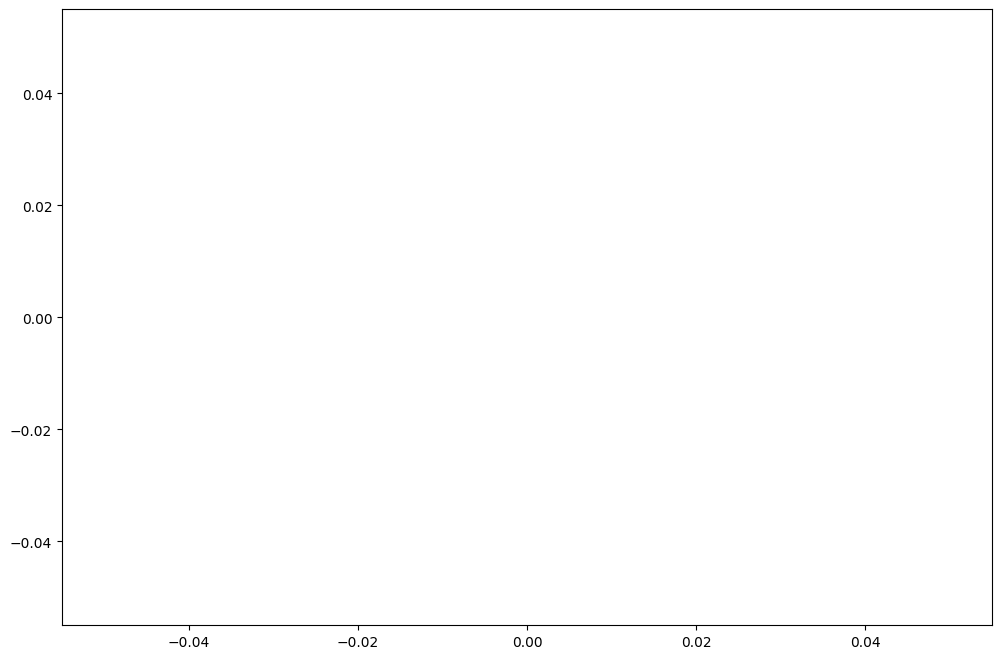

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import norm
import seaborn as sns

# Remove NaN values
revenue_data = np.array(revenues)/50

# Calculate statistics
mean_revenue = np.mean(revenue_data)
std_revenue = np.std(revenue_data, ddof=1)  # Sample standard deviation
median_revenue = np.median(revenue_data)
skewness = stats.skew(revenue_data)
kurtosis = stats.kurtosis(revenue_data)

print(f"Statistics:")
print(f"Sample size: {len(revenues)}")
print(f"Mean (μ): {mean_revenue:.4f}")
print(f"Standard deviation (σ): {std_revenue:.4f}")
print(f"Median: {median_revenue:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

# Create figure
plt.figure(figsize=(12, 8))

# Plot histogram
n_bins = 500
counts, bins, patches = plt.hist(revenue_data, bins=n_bins, density=True, 
                                alpha=0.7, color='skyblue', edgecolor='black', 
                                label='Actual Distribution')

# Generate normal distribution fit curve
x = np.linspace(revenue_data.min(), revenue_data.max(), 1000)
fitted_normal = norm.pdf(x, mean_revenue, std_revenue)
plt.plot(x, fitted_normal, 'r-', linewidth=2, 
         label=f'Normal Distribution Fit\nμ={mean_revenue:.3f}, σ={std_revenue:.3f}')

# Add mean and median lines
plt.axvline(mean_revenue, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_revenue:.3f}')
plt.axvline(median_revenue, color='orange', linestyle='--', linewidth=2, 
            label=f'Median: {median_revenue:.3f}')

# Plot settings
plt.xlabel('Revenue Values', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Revenue Distribution Histogram with Normal Distribution Fit', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show plot
plt.show()

# Kolmogorov-Smirnov normality test
ks_statistic, ks_p_value = stats.kstest(revenue_data, 
                                        lambda x: norm.cdf(x, mean_revenue, std_revenue))

# Shapiro-Wilk normality test (suitable for small samples)
if len(revenue_data) <= 5000:
    sw_statistic, sw_p_value = stats.shapiro(revenue_data)
    print(f"\nShapiro-Wilk Normality Test:")
    print(f"Test statistic: {sw_statistic:.4f}")
    print(f"p-value: {sw_p_value:.4e}")
    print(f"Conclusion: {'Accept normality assumption' if sw_p_value > 0.05 else 'Reject normality assumption'}")

print(f"\nKolmogorov-Smirnov Normality Test:")
print(f"Test statistic: {ks_statistic:.4f}")
print(f"p-value: {ks_p_value:.4e}")
print(f"Conclusion: {'Accept normality assumption' if ks_p_value > 0.05 else 'Reject normality assumption'}")

# Calculate goodness of fit (R²)
bin_centers = (bins[:-1] + bins[1:]) / 2
expected_counts = len(revenue_data) * norm.pdf(bin_centers, mean_revenue, std_revenue) * (bins[1] - bins[0])
observed_counts = counts * len(revenue_data) * (bins[1] - bins[0])

# Calculate R²
ss_res = np.sum((observed_counts - expected_counts) ** 2)
ss_tot = np.sum((observed_counts - np.mean(observed_counts)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

print(f"\nGoodness of Fit:")
print(f"R² = {r_squared:.4f}")

# Plot Q-Q plot for normality check
plt.figure(figsize=(8, 6))
stats.probplot(revenue_data, dist="norm", plot=plt)
plt.title('Q-Q Plot: Normality Check')
plt.grid(True, alpha=0.3)
plt.show()

# Output normal distribution parameter summary
print(f"\nNormal Distribution Fit Results:")
print(f"Normal Distribution: N({mean_revenue:.4f}, {std_revenue:.4f}²)")
print(f"95% Confidence Interval: [{mean_revenue - 1.96*std_revenue:.4f}, {mean_revenue + 1.96*std_revenue:.4f}]")
print(f"99% Confidence Interval: [{mean_revenue - 2.58*std_revenue:.4f}, {mean_revenue + 2.58*std_revenue:.4f}]")

In [ ]:
revenue_series = pd.Series(revenues)

for stat in stats_global.keys():
    series = pd.Series(stats_global[stat])
    revenue_series = revenue_series.iloc[-len(series):]
    corr = series.corr(revenue_series)
    print(f"Correlation between {stat} and revenues: {corr:.4f}")
    series.to_csv(f"stat_{stat}.csv", index=False)


Correlation between residual_diff and revenues: 0.0089
Correlation between residual_std and revenues: -0.0066
Correlation between residual_mean and revenues: -0.0159
Correlation between residual_z_all and revenues: -0.0045
Correlation between residual_z_selected and revenues: -0.0052
Correlation between residual_sign and revenues: 0.0011
Correlation between corr_all and revenues: 0.0057
Correlation between corr_selected and revenues: 0.0113
Correlation between coef_adj_all and revenues: 0.0163
Correlation between coef_adj_selected and revenues: 0.0404


In [ ]:
revenue_series.to_csv("revenues.csv", index=False)

In [ ]:
revenue_series.max(), revenue_series.min(), revenue_series.mean(), revenue_series.std()

(np.float64(4.49893730509566),
 np.float64(-5.55714705995502),
 np.float64(0.0029148537674451723),
 np.float64(0.18845025083757147))

In [ ]:
fit_ratio = 0.8 # 70% 用于训练，30% 用于测试
split_index = int(len(revenue_series) * fit_ratio)
train_revenues = revenue_series[:split_index]
test_revenues = revenue_series[split_index:]
train_revenue_series = np.array(train_revenues)
test_revenue_series = np.array(test_revenues)

train_stats_global = {}
test_stats_global = {}
for stat in stats_global.keys():
    series = pd.Series(stats_global[stat])
    train_stats_global[stat] = series[:split_index] 
    test_stats_global[stat] = series[split_index:]

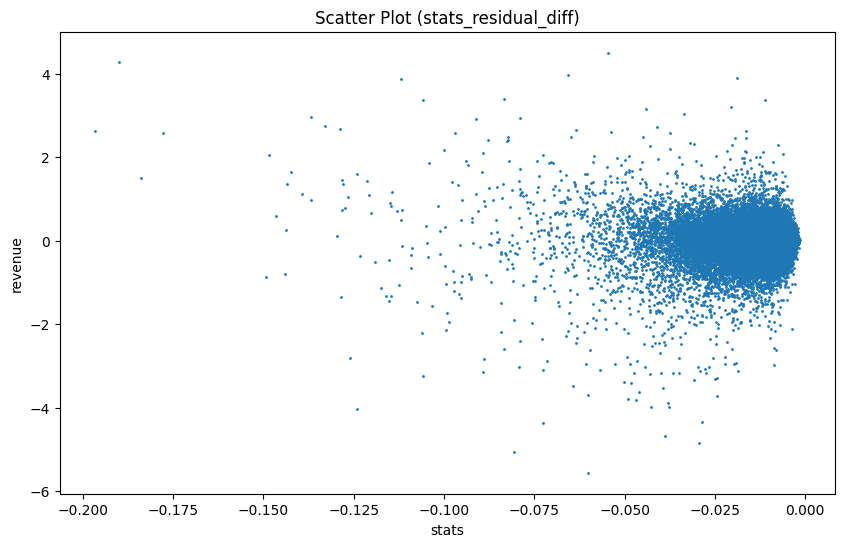

<Figure size 1200x600 with 0 Axes>

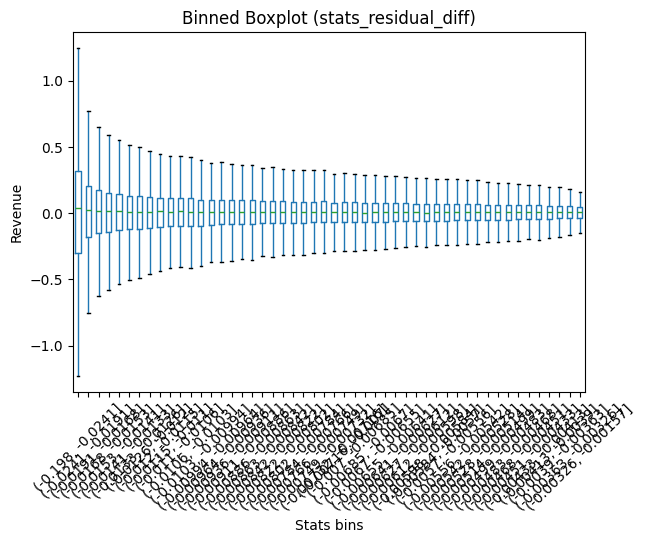

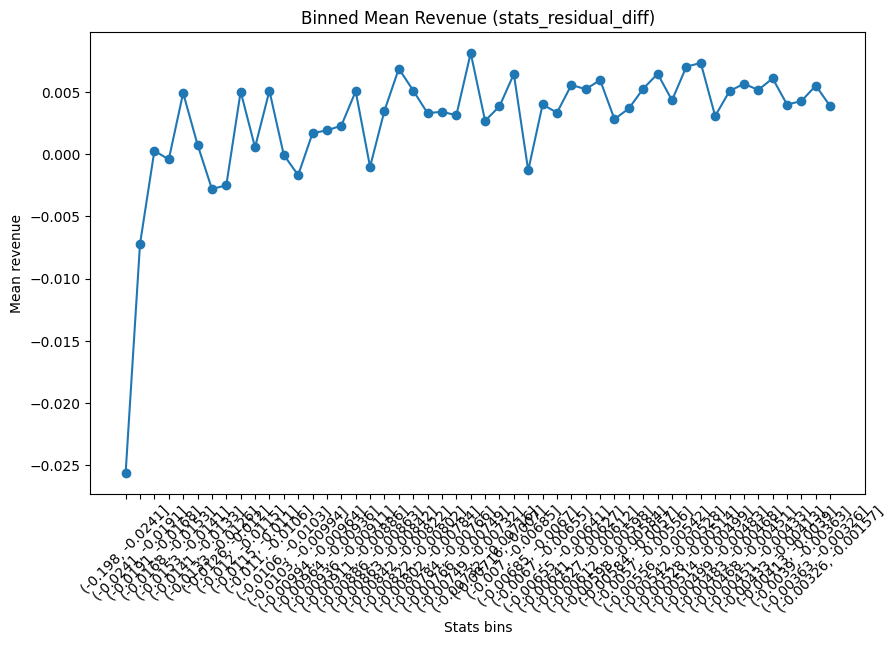


Summary statistics for stats_residual_diff:
                      count      mean    median       std
bin                                                      
(-0.198, -0.0241]      5194 -0.025607  0.034993  0.722333
(-0.0241, -0.0191]     5194 -0.007221  0.022140  0.375537
(-0.0191, -0.0168]     5194  0.000268  0.017034  0.319205
(-0.0168, -0.0153]     5194 -0.000438  0.014167  0.286189
(-0.0153, -0.0141]     5193  0.004903  0.015407  0.255074
(-0.0141, -0.0133]     5194  0.000759  0.011783  0.238584
(-0.0133, -0.0126]     5194 -0.002802  0.006802  0.229695
(-0.0126, -0.012]      5194 -0.002513  0.006468  0.225271
(-0.012, -0.0115]      5193  0.005012  0.016001  0.210094
(-0.0115, -0.011]      5194  0.000542  0.010468  0.204923
(-0.011, -0.0106]      5194  0.005075  0.013152  0.191744
(-0.0106, -0.0103]     5194 -0.000069  0.008943  0.195057
(-0.0103, -0.00994]    5193 -0.001693  0.006109  0.186656
(-0.00994, -0.00964]   5194  0.001677  0.009301  0.178959
(-0.00964, -0.00936]   5194

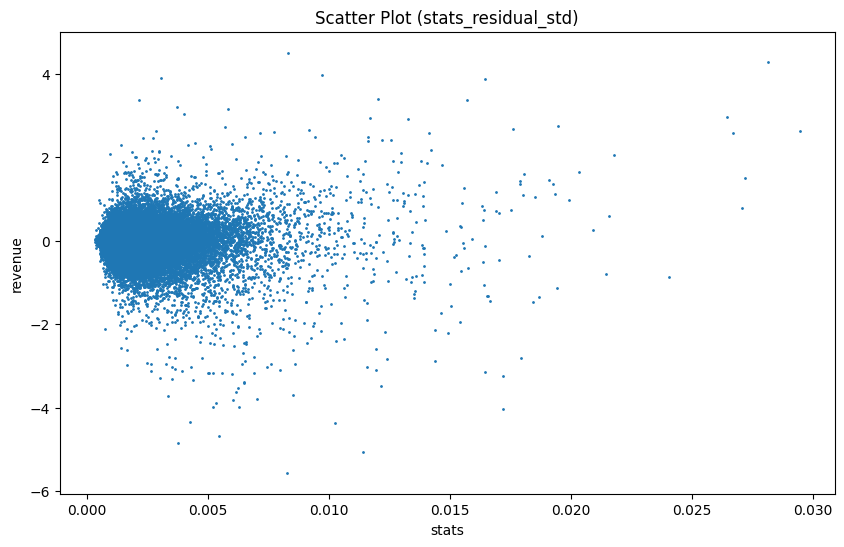

<Figure size 1200x600 with 0 Axes>

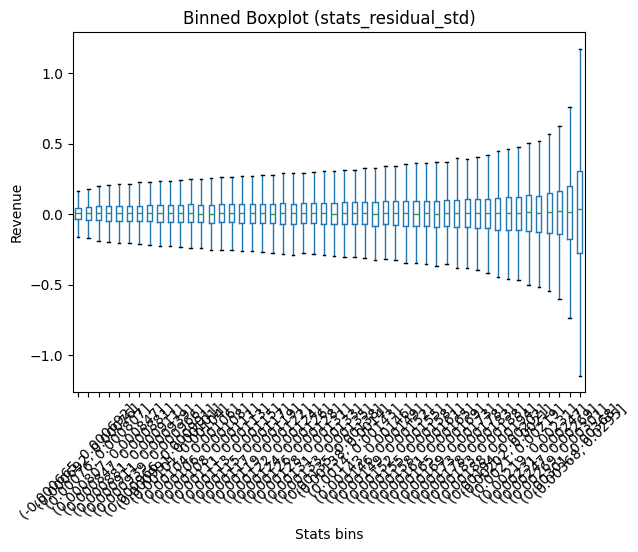

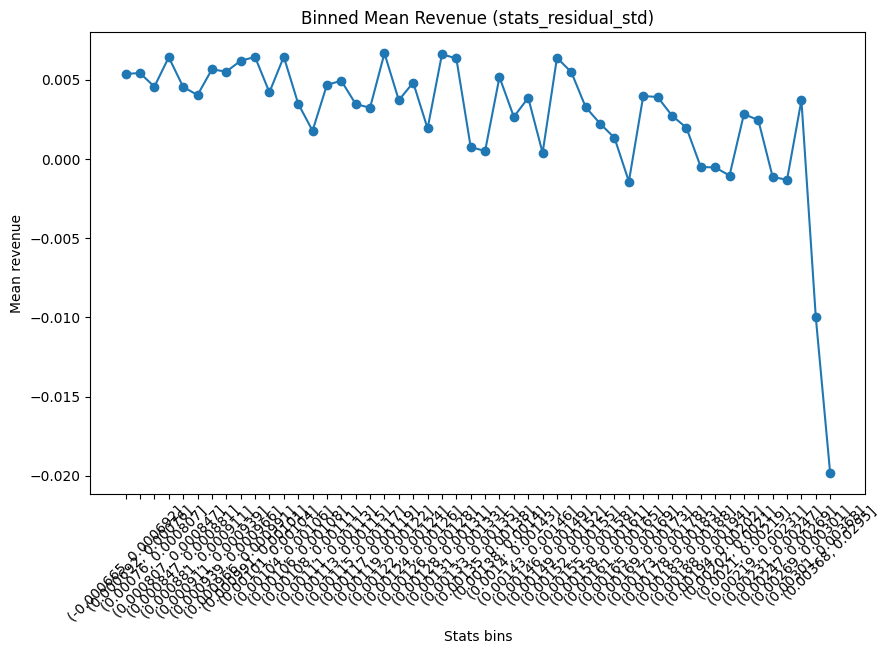


Summary statistics for stats_residual_std:
                       count      mean    median       std
bin                                                       
(-0.000665, 0.000692]   5194  0.005377  0.006272  0.084958
(0.000692, 0.00076]     5194  0.005420  0.006035  0.091133
(0.00076, 0.000807]     5194  0.004565  0.006946  0.096790
(0.000807, 0.000847]    5194  0.006422  0.007021  0.097881
(0.000847, 0.000881]    5193  0.004548  0.008149  0.100694
(0.000881, 0.000911]    5194  0.004035  0.006476  0.101482
(0.000911, 0.000939]    5194  0.005654  0.006858  0.103868
(0.000939, 0.000966]    5194  0.005516  0.007470  0.109677
(0.000966, 0.000991]    5193  0.006200  0.008573  0.108224
(0.000991, 0.00101]     5194  0.006438  0.007252  0.110447
(0.00101, 0.00104]      5194  0.004209  0.007325  0.113197
(0.00104, 0.00106]      5194  0.006453  0.009283  0.118456
(0.00106, 0.00108]      5193  0.003490  0.004213  0.112288
(0.00108, 0.00111]      5194  0.001781  0.005777  0.126083
(0.00111, 0.

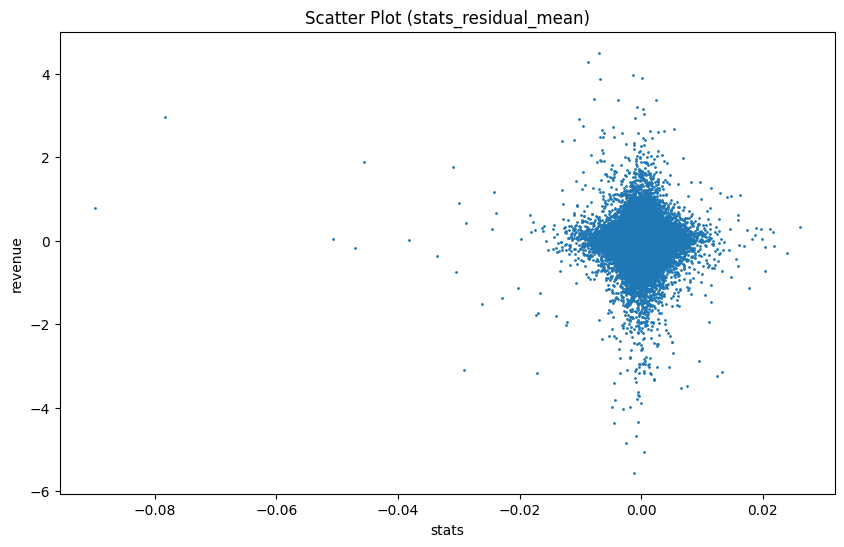

<Figure size 1200x600 with 0 Axes>

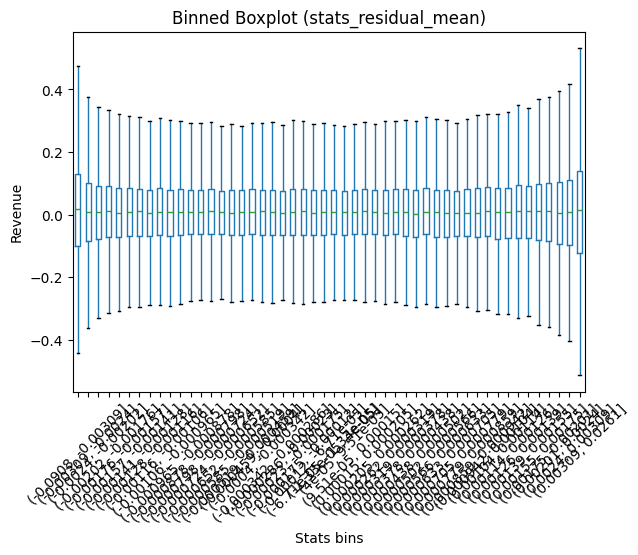

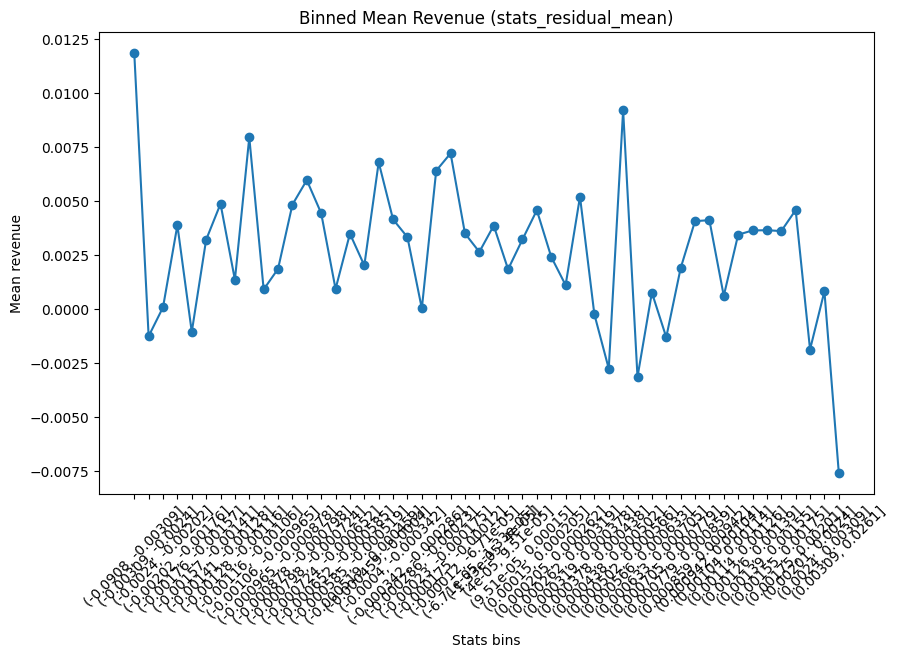


Summary statistics for stats_residual_mean:
                        count      mean    median       std
bin                                                        
(-0.0908, -0.00309]      5194  0.011846  0.019329  0.383661
(-0.00309, -0.0024]      5194 -0.001273  0.008571  0.254036
(-0.0024, -0.00202]      5194  0.000064  0.008748  0.210171
(-0.00202, -0.00176]     5194  0.003866  0.011266  0.213379
(-0.00176, -0.00157]     5193 -0.001076  0.004586  0.205611
(-0.00157, -0.00141]     5194  0.003195  0.009014  0.187016
(-0.00141, -0.00128]     5194  0.004855  0.009955  0.183696
(-0.00128, -0.00116]     5194  0.001338  0.006402  0.199482
(-0.00116, -0.00106]     5193  0.007931  0.006779  0.166449
(-0.00106, -0.000965]    5194  0.000891  0.006719  0.186757
(-0.000965, -0.000878]   5194  0.001844  0.007580  0.177625
(-0.000878, -0.000798]   5194  0.004818  0.007558  0.169222
(-0.000798, -0.000724]   5193  0.005951  0.009784  0.177501
(-0.000724, -0.000652]   5194  0.004422  0.009815  0.17

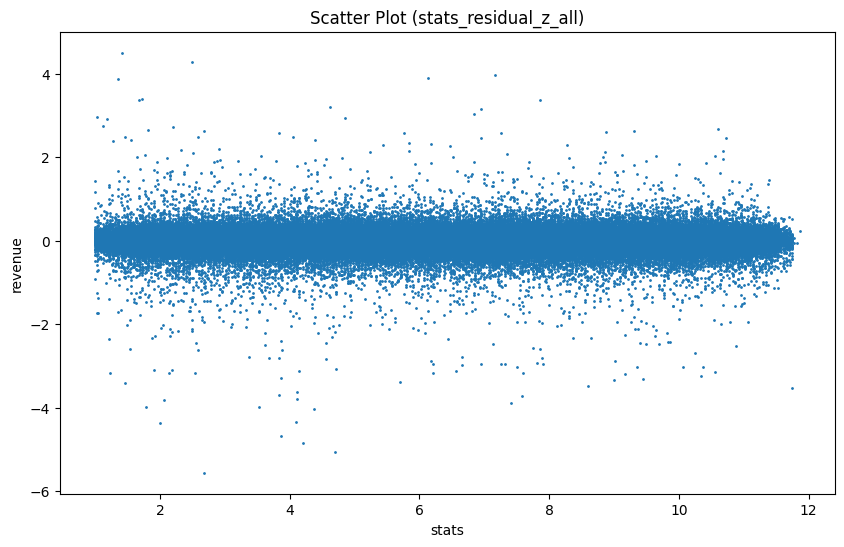

<Figure size 1200x600 with 0 Axes>

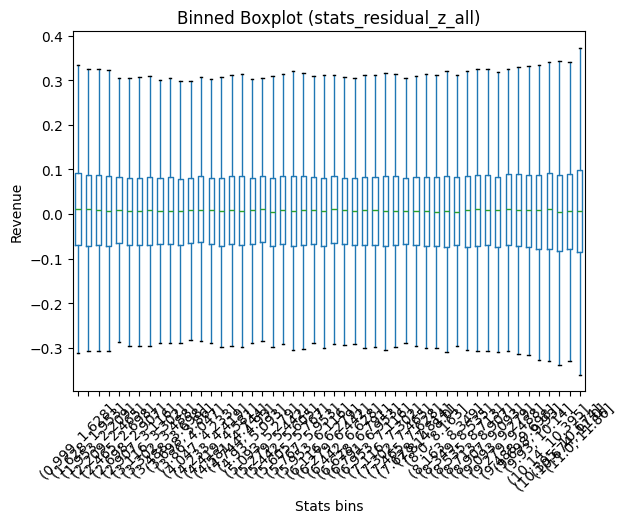

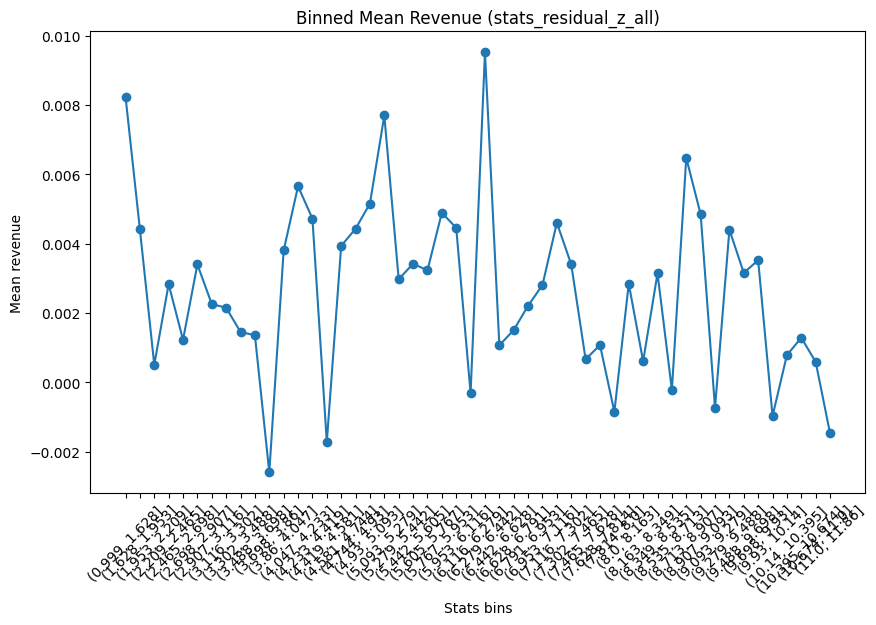


Summary statistics for stats_residual_z_all:
                  count      mean    median       std
bin                                                  
(0.999, 1.628]     5448  0.008241  0.010178  0.250932
(1.628, 1.953]     5262  0.004416  0.011342  0.232684
(1.953, 2.209]     4952  0.000505  0.009342  0.239523
(2.209, 2.465]     5522  0.002830  0.006410  0.197459
(2.465, 2.698]     5358  0.001226  0.009726  0.234145
(2.698, 2.907]     4993  0.003398  0.006670  0.188326
(2.907, 3.116]     5310  0.002256  0.007183  0.185149
(3.116, 3.302]     4961  0.002150  0.008299  0.180145
(3.302, 3.488]     5000  0.001450  0.006282  0.188399
(3.488, 3.698]     5771  0.001358  0.007114  0.202701
(3.698, 3.86]      4613 -0.002599  0.006782  0.212035
(3.86, 4.047]      5226  0.003803  0.009534  0.180204
(4.047, 4.233]     5481  0.005651  0.008524  0.214225
(4.233, 4.419]     5458  0.004723  0.009290  0.196214
(4.419, 4.581]     4920 -0.001723  0.007285  0.187686
(4.581, 4.744]     4861  0.003934  0

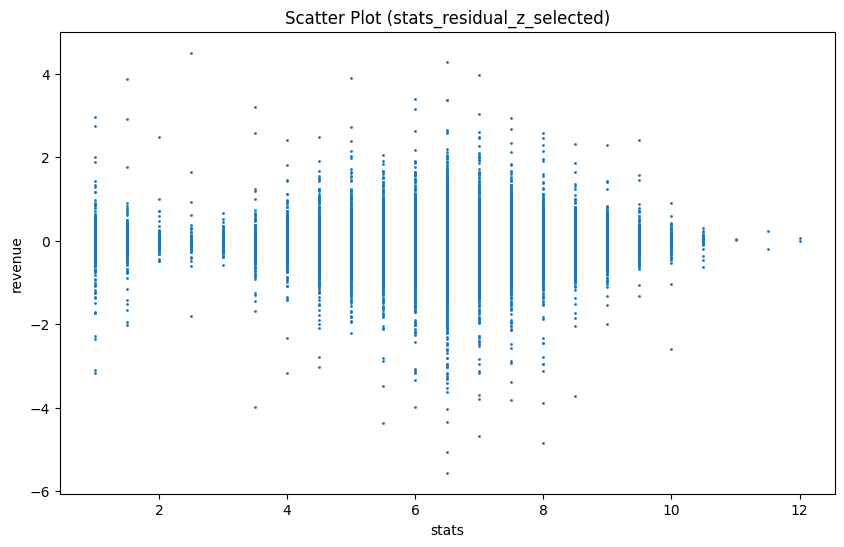

<Figure size 1200x600 with 0 Axes>

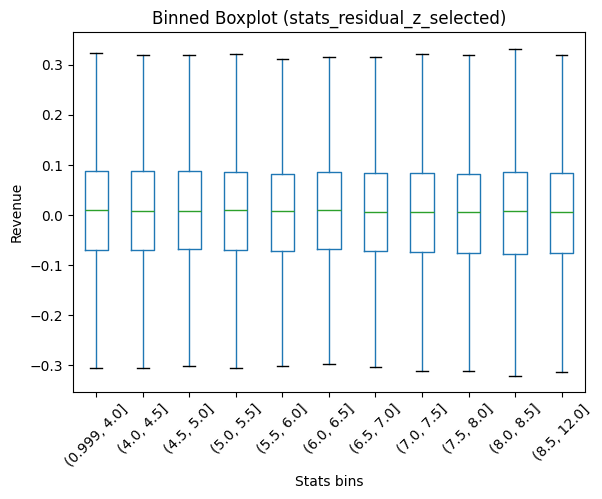

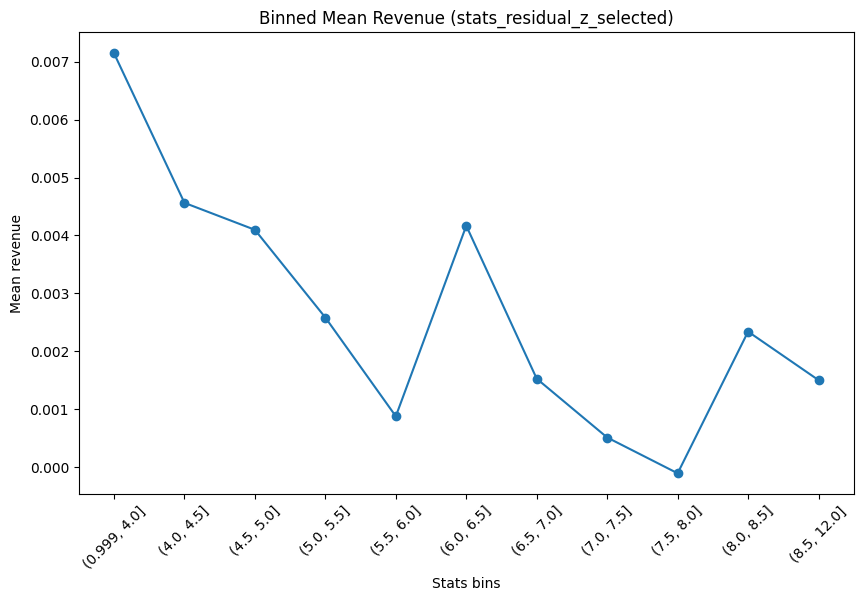


Summary statistics for stats_residual_z_selected:
              count      mean    median       std
bin                                              
(0.999, 4.0]   7886  0.007146  0.010249  0.244537
(4.0, 4.5]     6204  0.004563  0.007592  0.207662
(4.5, 5.0]    11450  0.004097  0.008910  0.198940
(5.0, 5.5]    20260  0.002582  0.009342  0.194063
(5.5, 6.0]    37935  0.000877  0.007293  0.190015
(6.0, 6.5]    93780  0.004167  0.009496  0.191145
(6.5, 7.0]    38484  0.001526  0.006661  0.192533
(7.0, 7.5]    21079  0.000511  0.006272  0.198760
(7.5, 8.0]    11912 -0.000107  0.005972  0.209357
(8.0, 8.5]     6424  0.002339  0.007156  0.194431
(8.5, 12.0]    4275  0.001501  0.006660  0.196372


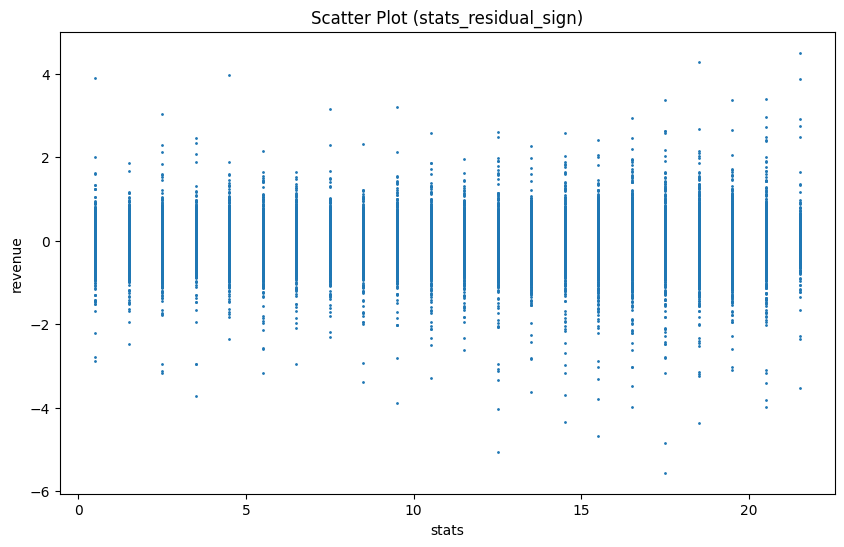

<Figure size 1200x600 with 0 Axes>

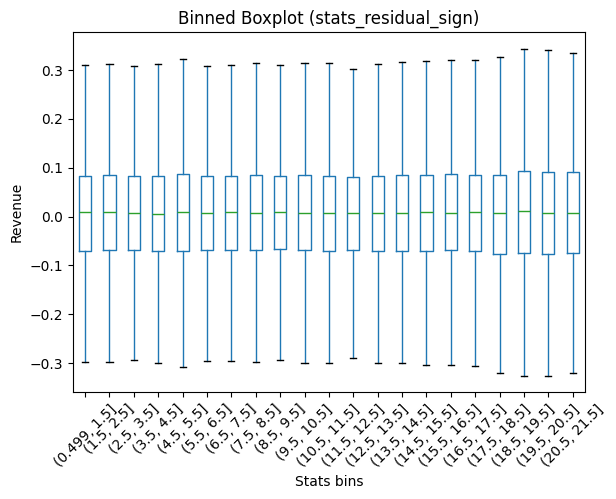

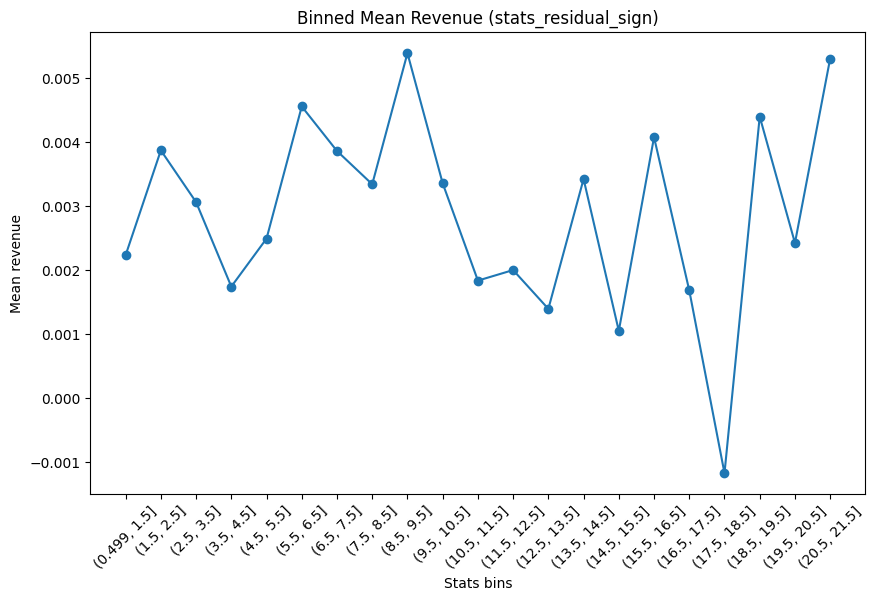


Summary statistics for stats_residual_sign:
              count      mean    median       std
bin                                              
(0.499, 1.5]  21155  0.002232  0.008756  0.179882
(1.5, 2.5]    10771  0.003869  0.009499  0.190419
(2.5, 3.5]    10788  0.003060  0.006844  0.183330
(3.5, 4.5]    10897  0.001740  0.006163  0.185893
(4.5, 5.5]    10978  0.002490  0.009312  0.187891
(5.5, 6.5]    11216  0.004555  0.007954  0.177489
(6.5, 7.5]    11192  0.003859  0.009637  0.180474
(7.5, 8.5]    11333  0.003339  0.007712  0.181382
(8.5, 9.5]    11768  0.005387  0.008785  0.184198
(9.5, 10.5]   12064  0.003355  0.007475  0.188229
(10.5, 11.5]  12262  0.001834  0.007599  0.181111
(11.5, 12.5]  12444  0.001999  0.007991  0.201244
(12.5, 13.5]  13076  0.001392  0.006899  0.190770
(13.5, 14.5]  13671  0.003421  0.008097  0.197668
(14.5, 15.5]  14119  0.001048  0.009506  0.200967
(15.5, 16.5]  14889  0.004074  0.008148  0.210939
(16.5, 17.5]  15103  0.001680  0.008979  0.212721
(17.5

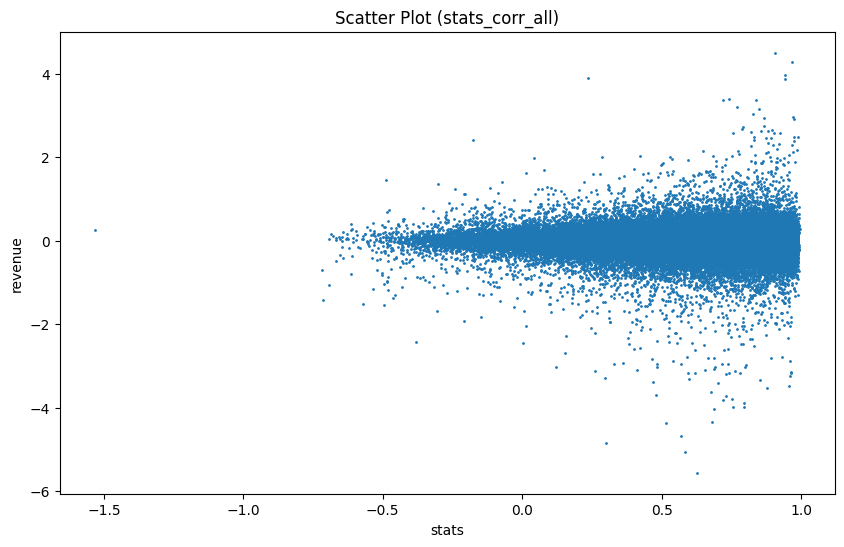

<Figure size 1200x600 with 0 Axes>

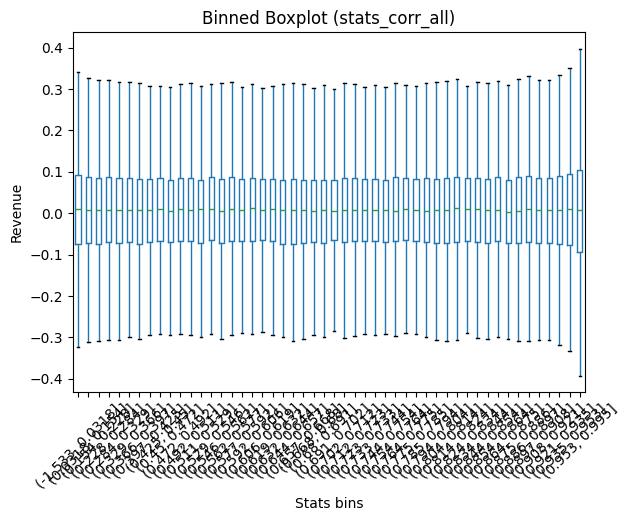

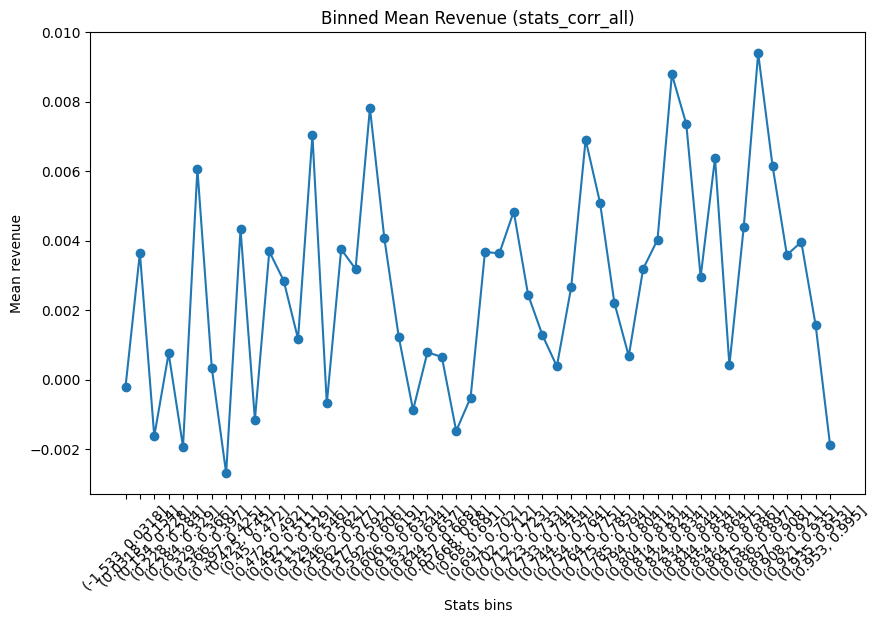


Summary statistics for stats_corr_all:
                  count      mean    median       std
bin                                                  
(-1.533, 0.0318]   5194 -0.000214  0.010017  0.235997
(0.0318, 0.154]    5194  0.003647  0.006856  0.208389
(0.154, 0.228]     5194 -0.001631  0.007776  0.194382
(0.228, 0.284]     5194  0.000756  0.006612  0.204925
(0.284, 0.329]     5193 -0.001936  0.008387  0.209547
(0.329, 0.366]     5194  0.006067  0.007496  0.181247
(0.366, 0.397]     5194  0.000337  0.006984  0.185697
(0.397, 0.425]     5194 -0.002700  0.008034  0.206677
(0.425, 0.45]      5193  0.004327  0.010339  0.182476
(0.45, 0.472]      5194 -0.001155  0.005641  0.195257
(0.472, 0.492]     5194  0.003691  0.011253  0.188929
(0.492, 0.511]     5194  0.002850  0.008153  0.179230
(0.511, 0.529]     5193  0.001170  0.009029  0.201411
(0.529, 0.546]     5194  0.007039  0.011008  0.190765
(0.546, 0.562]     5194 -0.000689  0.006192  0.181759
(0.562, 0.577]     5194  0.003755  0.01021

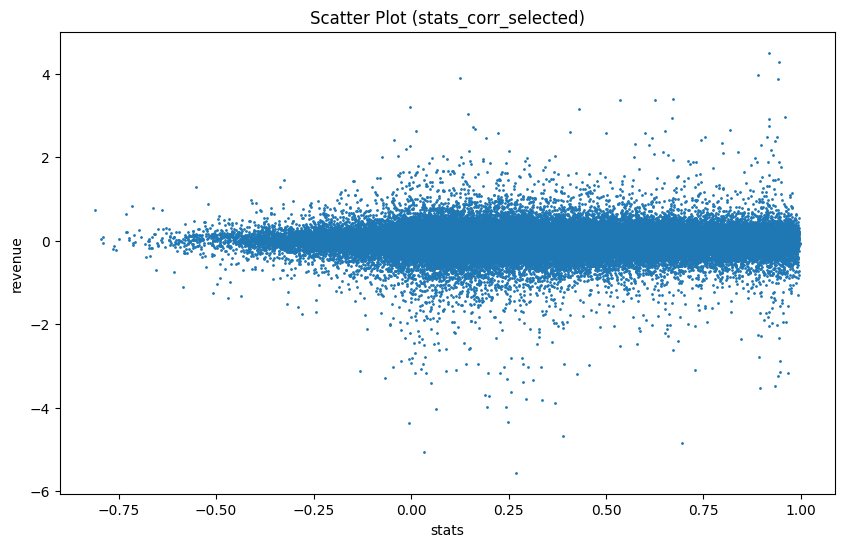

<Figure size 1200x600 with 0 Axes>

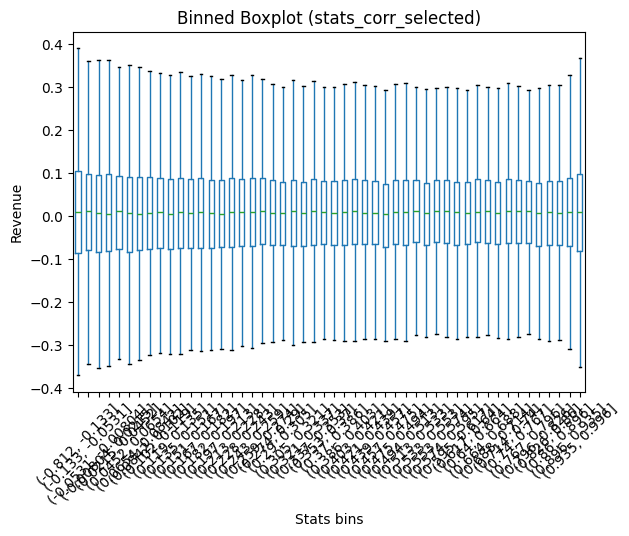

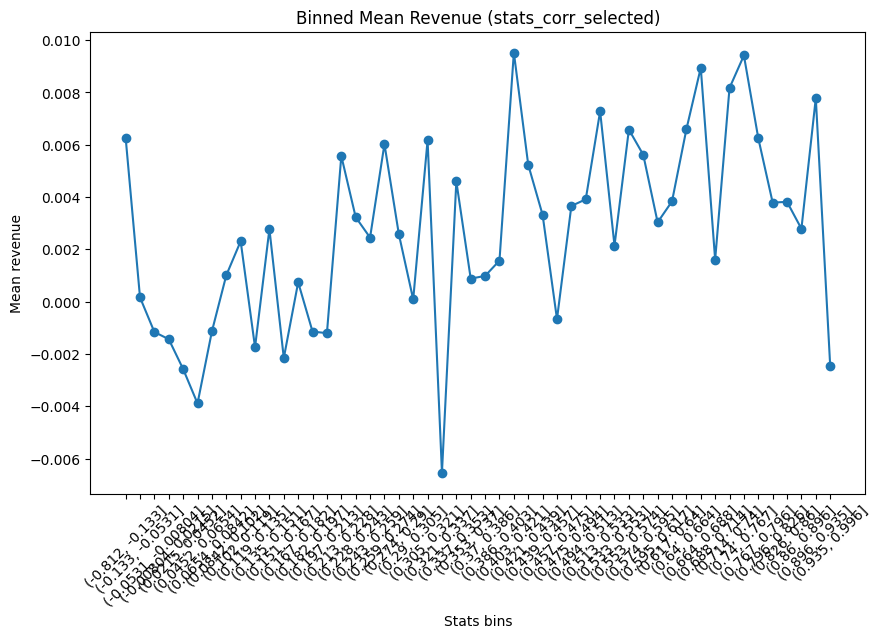


Summary statistics for stats_corr_selected:
                     count      mean    median       std
bin                                                     
(-0.812, -0.133]      5194  0.006266  0.008873  0.229499
(-0.133, -0.0531]     5194  0.000158  0.011473  0.224052
(-0.0531, -0.00804]   5194 -0.001165  0.007006  0.237511
(-0.00804, 0.0215]    5194 -0.001440  0.003822  0.264106
(0.0215, 0.0452]      5193 -0.002581  0.010271  0.244066
(0.0452, 0.0654]      5194 -0.003894  0.005975  0.229782
(0.0654, 0.0842]      5194 -0.001142  0.004644  0.220717
(0.0842, 0.102]       5194  0.001002  0.006462  0.201505
(0.102, 0.119]        5193  0.002304  0.008891  0.206592
(0.119, 0.135]        5194 -0.001748  0.003725  0.205638
(0.135, 0.151]        5194  0.002770  0.008642  0.207569
(0.151, 0.167]        5194 -0.002158  0.007541  0.211038
(0.167, 0.182]        5193  0.000736  0.008995  0.192996
(0.182, 0.197]        5194 -0.001150  0.007240  0.207779
(0.197, 0.213]        5194 -0.001207  0.004

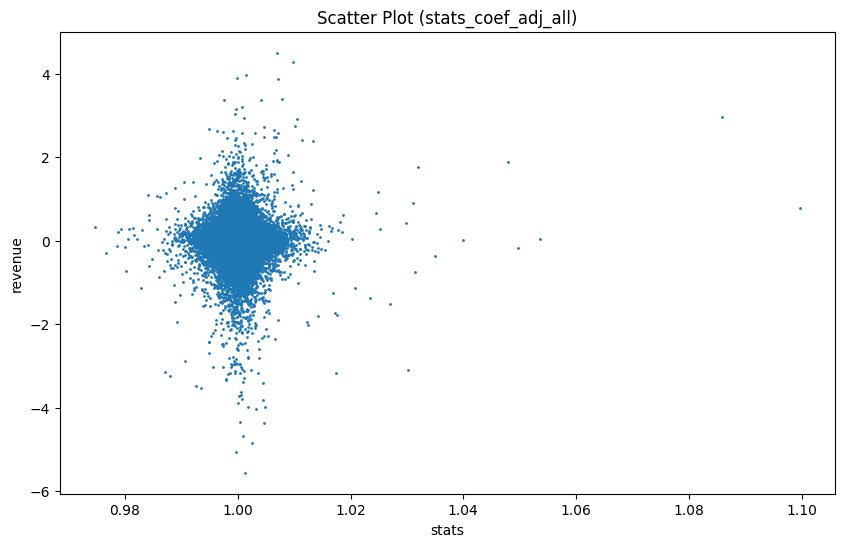

<Figure size 1200x600 with 0 Axes>

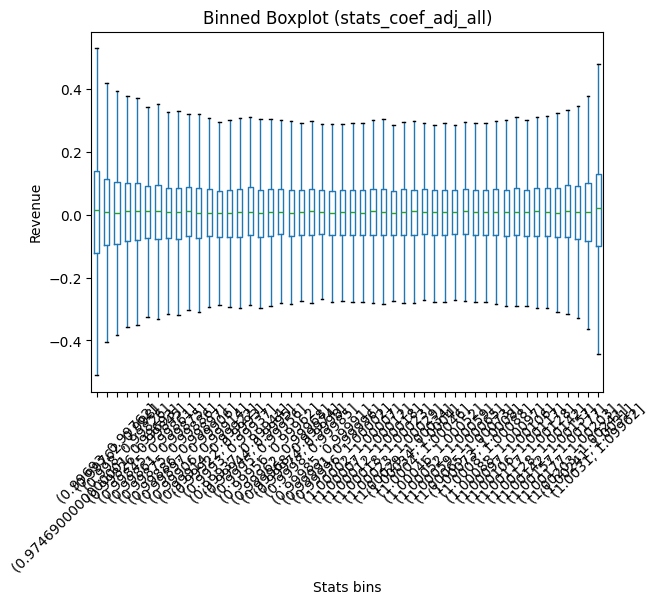

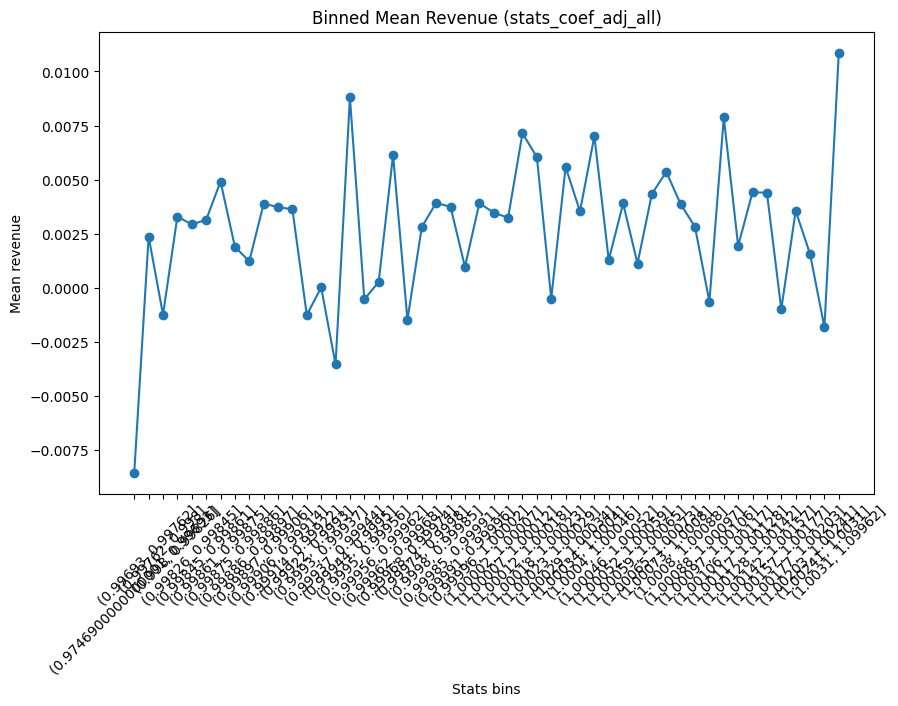


Summary statistics for stats_coef_adj_all:
                               count      mean    median       std
bin                                                               
(0.9746900000000001, 0.99693]   5194 -0.008548  0.013111  0.324884
(0.99693, 0.99762]              5194  0.002363  0.008552  0.261460
(0.99762, 0.998]                5194 -0.001243  0.005874  0.231144
(0.998, 0.99826]                5194  0.003292  0.011171  0.208215
(0.99826, 0.99845]              5193  0.002928  0.011948  0.215570
(0.99845, 0.99861]              5194  0.003141  0.010112  0.203434
(0.99861, 0.99875]              5194  0.004912  0.010089  0.187643
(0.99875, 0.99886]              5194  0.001892  0.008239  0.187637
(0.99886, 0.99897]              5193  0.001226  0.007635  0.193927
(0.99897, 0.99906]              5194  0.003887  0.010193  0.183542
(0.99906, 0.99914]              5194  0.003732  0.006339  0.172768
(0.99914, 0.99922]              5194  0.003624  0.006251  0.174581
(0.99922, 0.9993] 

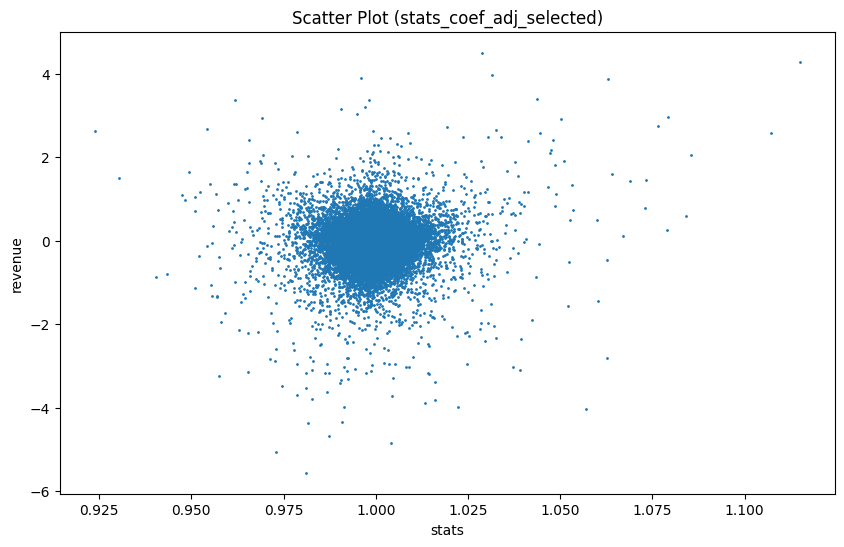

<Figure size 1200x600 with 0 Axes>

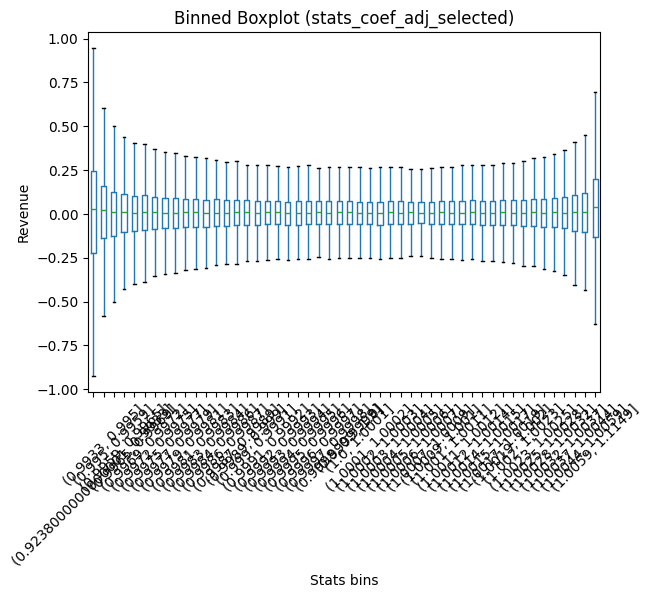

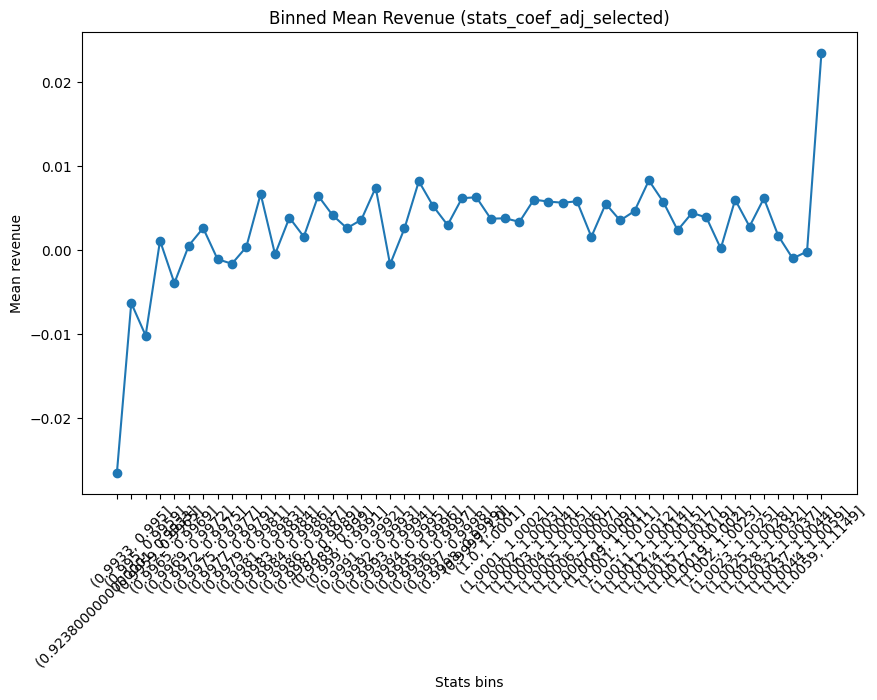


Summary statistics for stats_coef_adj_selected:
                              count      mean    median       std
bin                                                              
(0.9238000000000001, 0.9933]   5194 -0.026601  0.025002  0.562704
(0.9933, 0.995]                5194 -0.006311  0.019235  0.297416
(0.995, 0.9959]                5194 -0.010191  0.010473  0.253995
(0.9959, 0.9965]               5194  0.001132  0.009733  0.226176
(0.9965, 0.9969]               5193 -0.003931  0.007058  0.212035
(0.9969, 0.9972]               5194  0.000542  0.008381  0.194033
(0.9972, 0.9975]               5194  0.002633  0.011265  0.197970
(0.9975, 0.9977]               5194 -0.001078  0.005846  0.175999
(0.9977, 0.9979]               5193 -0.001629  0.007706  0.182705
(0.9979, 0.9981]               5194  0.000363  0.009069  0.168023
(0.9981, 0.9983]               5194  0.006702  0.008957  0.170281
(0.9983, 0.9984]               5194 -0.000502  0.005429  0.164867
(0.9984, 0.9986]           

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

n_bins = 50  # 分箱数量，可调整

for stat_name, stats in train_stats_global.items():
    i = stat_name
    df = pd.DataFrame({
        "stats": stats,
        "revenue": train_revenue_series
    }).dropna()

    # 等频分箱（推荐用于分布不均）
    df["bin"] = pd.qcut(df["stats"], q=n_bins, duplicates="drop")

    # 分箱统计
    bin_stats = df.groupby("bin")["revenue"].agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )

    # ===== 1. 原始散点图 =====
    plt.figure(figsize=(10, 6))
    plt.scatter(df["stats"], df["revenue"], s=1)
    plt.xlabel("stats")
    plt.ylabel("revenue")
    plt.title(f"Scatter Plot (stats_{i})")
    plt.show()
    plt.close()

    # ===== 2. 分箱箱线图 =====
    plt.figure(figsize=(12, 6))
    df.boxplot(
        column="revenue",
        by="bin",
        showfliers=False,
        grid=False
    )
    plt.xticks(rotation=45)
    plt.xlabel("Stats bins")
    plt.ylabel("Revenue")
    plt.title(f"Binned Boxplot (stats_{i})")
    plt.suptitle("")
    plt.show()
    plt.close()

    # ===== 3. 分箱均值曲线 =====
    plt.figure(figsize=(10, 6))
    plt.plot(
        range(len(bin_stats)),
        bin_stats["mean"].values,
        marker="o"
    )
    plt.xticks(range(len(bin_stats)), bin_stats.index.astype(str), rotation=45)
    plt.xlabel("Stats bins")
    plt.ylabel("Mean revenue")
    plt.title(f"Binned Mean Revenue (stats_{i})")
    plt.show()
    plt.close()

    # ===== 4. 输出统计表 =====
    print(f"\nSummary statistics for stats_{i}:")
    print(bin_stats)


In [ ]:
y_train=train_revenue_series/50 * 10000
X_train=pd.DataFrame(train_stats_global)

y_test=test_revenue_series/50 * 10000
X_test=pd.DataFrame(test_stats_global)
def model_evaluation(y_true, y_pred, dataset_type="Train"):
    from sklearn.metrics import mean_squared_error, r2_score
    import matplotlib.pyplot as plt
    
    mse = mean_squared_error(y_true, y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    std = y_true.std()
    
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    relative_mae = mae / std if std != 0 else float('inf')
    relative_rmse = rmse / std if std != 0 else float('inf')
    
    # 存储每个百分位的结果
    percentiles = []
    true_means = []
    pred_means = []
    sample_counts = []
    
    for top_pct in np.arange(0.002, 0.5, 0.002):
        threshold = np.percentile(y_pred, (1-top_pct) * 100)  # 选择最大的top_pct比例
        mask = y_pred >= threshold
        filtered_y_true = y_true[mask]
        filtered_y_pred = y_pred[mask]
        
        if len(filtered_y_true) > 0:  # 确保有数据
            percentiles.append(top_pct)
            true_means.append(np.mean(filtered_y_true))
            pred_means.append(np.mean(filtered_y_pred))
            sample_counts.append(len(filtered_y_true))
    
    # 计算总体均值
    overall_true_mean = np.mean(y_true)
    overall_pred_mean = np.mean(y_pred)
    
    # 绘制折线图
    plt.figure(figsize=(12, 8))
    
    # 主图：均值对比
    plt.subplot(2, 1, 1)
    plt.plot(percentiles, true_means, 'b-o', label=f'True Mean', linewidth=2, markersize=4)
    plt.plot(percentiles, pred_means, 'r-s', label=f'Pred Mean', linewidth=2, markersize=4)
    plt.axhline(y=overall_true_mean, color='blue', linestyle='--', alpha=0.7, 
                label=f'Overall True Mean: {overall_true_mean:.4f}')
    plt.axhline(y=overall_pred_mean, color='red', linestyle='--', alpha=0.7,
                label=f'Overall Pred Mean: {overall_pred_mean:.4f}')
    plt.axhline(y=10, color='black', linestyle='--', alpha=0.7,
            label=f'cost baseline: 10')
    
    plt.xlabel('Top Percentile Threshold')
    plt.ylabel('Mean Value')
    plt.title(f'{dataset_type} Set: Mean Values by Percentile Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 副图：样本数量
    plt.subplot(2, 1, 2)
    plt.plot(percentiles, sample_counts, 'g-^', label='Sample Count', linewidth=2, markersize=4)
    plt.xlabel('Top Percentile Threshold')
    plt.ylabel('Sample Count')
    plt.title('Sample Count by Percentile Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 输出基本评估指标
    print(f"{dataset_type} Set Evaluation:")
    print(f"  MAE: {mae:.4f}, Relative MAE: {relative_mae:.4f}")
    print(f"  RMSE: {rmse:.4f}, Relative RMSE: {relative_rmse:.4f}")
    print(f"  R²: {r2:.4f}")
    print(f"  Overall True Mean: {overall_true_mean:.4f}")
    print(f"  Overall Pred Mean: {overall_pred_mean:.4f}\n")
    
    # 输出百分位分析表
    percentile_df = pd.DataFrame({
        'Percentile': percentiles,
        'True_Mean': true_means,
        'Pred_Mean': pred_means,
        'Sample_Count': sample_counts,
        'Mean_Diff': np.array(pred_means) - np.array(true_means)
    })
    
    print(f"{dataset_type} Set Percentile Analysis:")
    print(percentile_df.round(4))
    
    # return percentile_df

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)


In [ ]:
!pip install lightgbm

In [ ]:
!pip install lightgbm

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import validation_curve
import numpy as np

# Random Forest 参数设置
model = RandomForestRegressor(
    n_estimators=1000,          # 树的数量
    max_depth=10,               # 最大深度，防止过拟合
    min_samples_split=500,      # 内部节点再划分所需最小样本数
    min_samples_leaf=250,       # 叶子节点最少样本数
    
    # 抽样参数
    max_samples=0.8,            # 每棵树使用的样本比例
    max_features=0.8,           # 每棵树使用的特征比例
    
    n_jobs=-1,
    random_state=42
)

# 数据分割
random_90pct_index = np.random.permutation(len(X_train))

X_train_90pct = X_train.iloc[random_90pct_index[:int(0.8*len(X_train))]]
y_train_90pct = y_train[random_90pct_index[:int(0.8*len(X_train))]]

X_train_10pct = X_train.iloc[random_90pct_index[int(0.8*len(X_train)):]]
y_train_10pct = y_train[random_90pct_index[int(0.8*len(X_train)):]]

# 训练模型
print("Training Random Forest...")
model.fit(X_train_90pct, y_train_90pct)

# 验证集评估 (手动实现早停效果)
from sklearn.metrics import mean_squared_error
val_score = mean_squared_error(y_train_10pct, model.predict(X_train_10pct))
print(f"验证集 MSE: {val_score:.4f}")

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

Training Random Forest...
验证集 MSE: 1543.1045


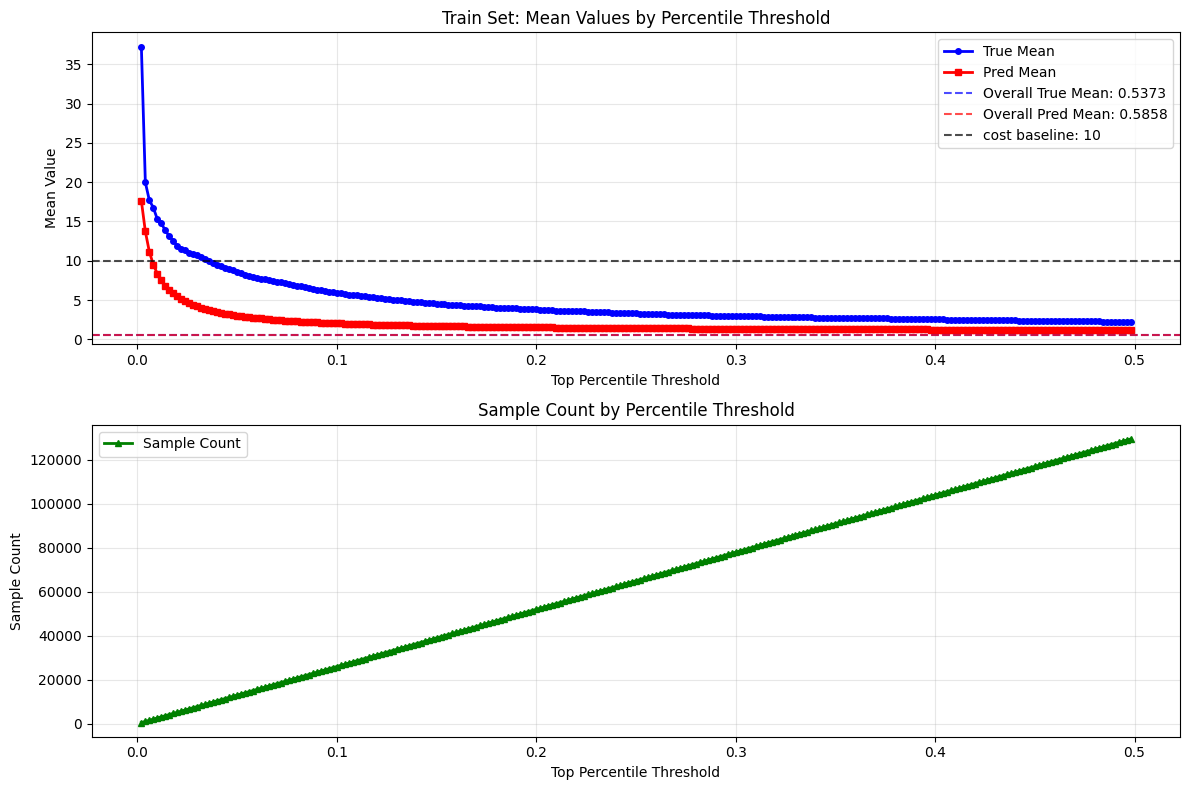

Train Set Evaluation:
  MAE: 23.7168, Relative MAE: 0.6061
  RMSE: 38.9560, Relative RMSE: 0.9955
  R²: 0.0089
  Overall True Mean: 0.5373
  Overall Pred Mean: 0.5858

Train Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    37.2627    17.6325           520   -19.6302
1         0.004    19.9633    13.7301          1039    -6.2332
2         0.006    17.6991    11.1493          1559    -6.5498
3         0.008    16.7721     9.5100          2078    -7.2621
4         0.010    15.2890     8.3656          2597    -6.9234
..          ...        ...        ...           ...        ...
244       0.490     2.2602     1.1933        127248    -1.0669
245       0.492     2.2578     1.1920        127767    -1.0658
246       0.494     2.2493     1.1908        128286    -1.0586
247       0.496     2.2416     1.1895        128806    -1.0522
248       0.498     2.2366     1.1882        129325    -1.0484

[249 rows x 5 columns]


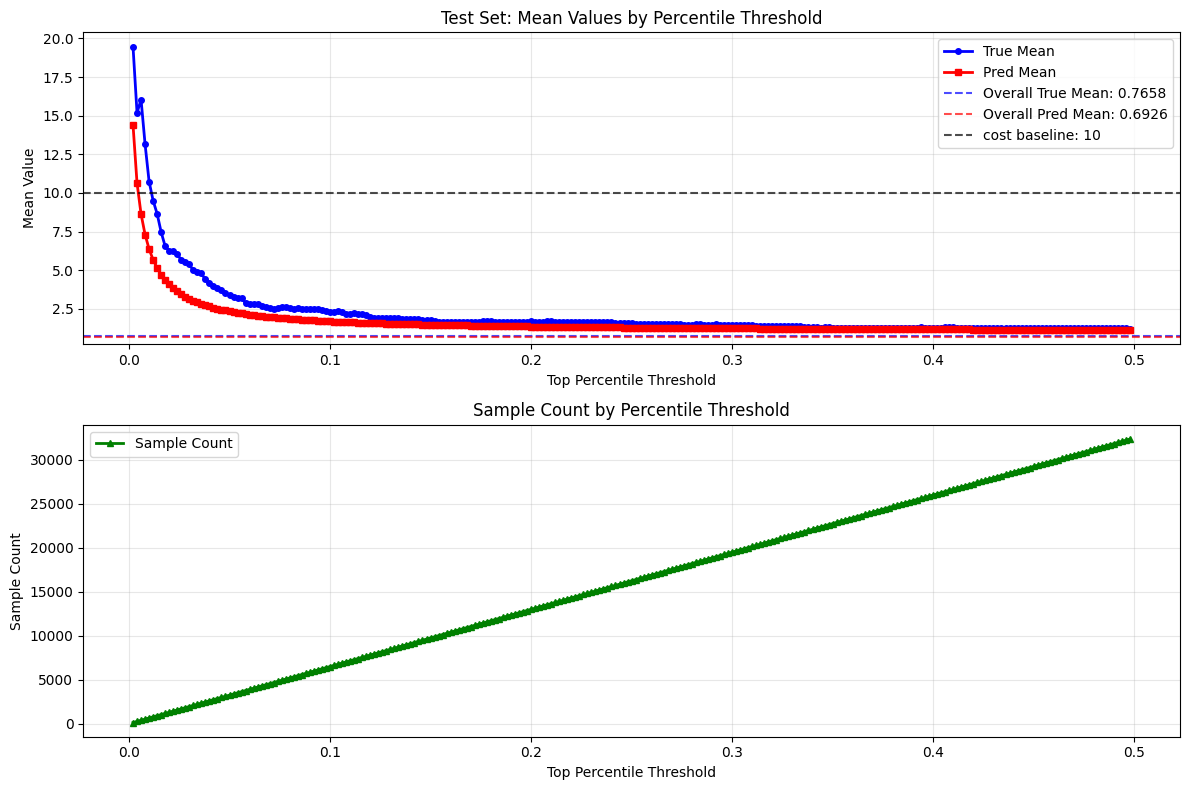

Test Set Evaluation:
  MAE: 19.1936, Relative MAE: 0.6138
  RMSE: 31.2599, Relative RMSE: 0.9996
  R²: 0.0008
  Overall True Mean: 0.7658
  Overall Pred Mean: 0.6926

Test Set Percentile Analysis:
     Percentile  True_Mean  Pred_Mean  Sample_Count  Mean_Diff
0         0.002    19.4729    14.4158           130    -5.0570
1         0.004    15.1800    10.6377           260    -4.5422
2         0.006    16.0426     8.6374           390    -7.4052
3         0.008    13.1565     7.3097           520    -5.8468
4         0.010    10.7394     6.3708           650    -4.3686
..          ...        ...        ...           ...        ...
244       0.490     1.2466     1.1355         31812    -0.1111
245       0.492     1.2427     1.1347         31942    -0.1080
246       0.494     1.2372     1.1338         32072    -0.1033
247       0.496     1.2338     1.1330         32202    -0.1008
248       0.498     1.2314     1.1322         32332    -0.0993

[249 rows x 5 columns]


In [ ]:

model_evaluation(y_train, y_train_pred, dataset_type="Train")
model_evaluation(y_test, y_test_pred, dataset_type="Test")

In [ ]:
y_true_filtered = []
for i in range(len(y_test)):
    if y_test_pred[i] >= 5:
        y_true_filtered.append(y_test[i])
    else:
        y_true_filtered.append(0)




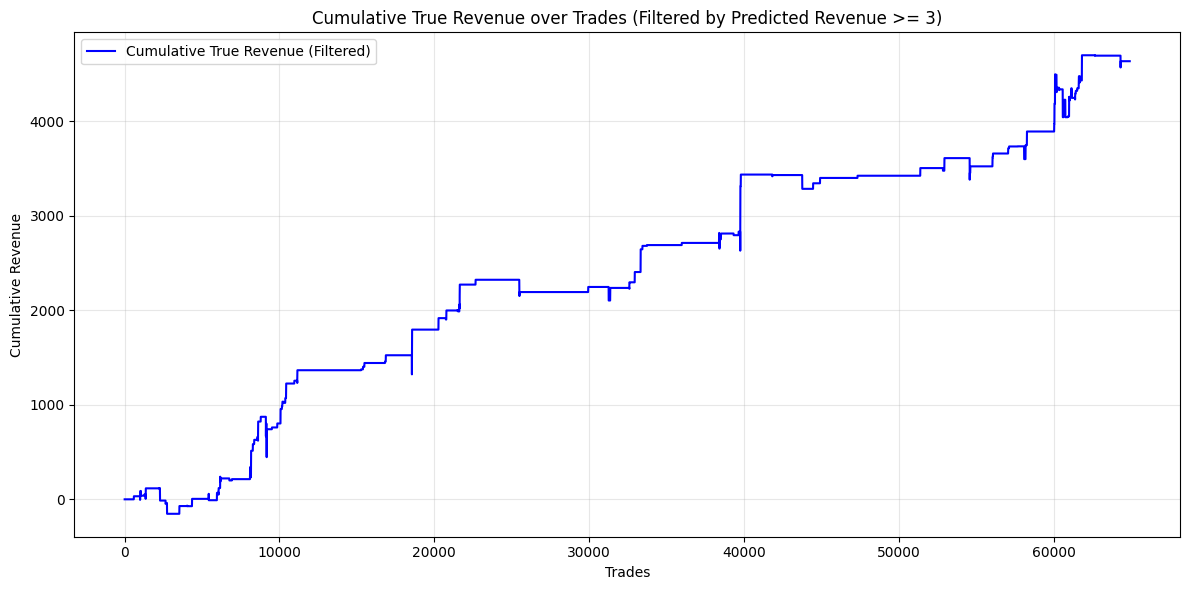

In [ ]:
y_true_filtered_cumsum = np.cumsum(y_true_filtered)

plt.figure(figsize=(12, 6))
plt.plot(y_true_filtered_cumsum, label='Cumulative True Revenue (Filtered)', color='blue')
plt.xlabel('Trades')
plt.ylabel('Cumulative Revenue')
plt.title('Cumulative True Revenue over Trades (Filtered by Predicted Revenue >= 3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [ ]:

# for stat_name, stats in test_stats_global.items():
#     i = stat_name
#     df = pd.DataFrame({
#         "stats": stats,
#         "revenue": test_revenue_series
#     }).dropna()

#     # 等频分箱（推荐用于分布不均）
#     df["bin"] = pd.qcut(df["stats"], q=n_bins, duplicates="drop")

#     # 分箱统计
#     bin_stats = df.groupby("bin")["revenue"].agg(
#         count="count",
#         mean="mean",
#         median="median",
#         std="std"
#     )

#     # ===== 1. 原始散点图 =====
#     plt.figure(figsize=(10, 6))
#     plt.scatter(df["stats"], df["revenue"], s=1)
#     plt.xlabel("stats")
#     plt.ylabel("revenue")
#     plt.title(f"Scatter Plot (stats_{i})")
#     plt.show()
#     plt.close()

#     # ===== 2. 分箱箱线图 =====
#     plt.figure(figsize=(12, 6))
#     df.boxplot(
#         column="revenue",
#         by="bin",
#         showfliers=False,
#         grid=False
#     )
#     plt.xticks(rotation=45)
#     plt.xlabel("Stats bins")
#     plt.ylabel("Revenue")
#     plt.title(f"Binned Boxplot (stats_{i})")
#     plt.suptitle("")
#     plt.show()
#     plt.close()

#     # ===== 3. 分箱均值曲线 =====
#     plt.figure(figsize=(10, 6))
#     plt.plot(
#         range(len(bin_stats)),
#         bin_stats["mean"].values,
#         marker="o"
#     )
#     plt.xticks(range(len(bin_stats)), bin_stats.index.astype(str), rotation=45)
#     plt.xlabel("Stats bins")
#     plt.ylabel("Mean revenue")
#     plt.title(f"Binned Mean Revenue (stats_{i})")
#     plt.show()
#     plt.close()

#     # ===== 4. 输出统计表 =====
#     print(f"\nSummary statistics for stats_{i}:")
#     print(bin_stats)
